[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_02/SFM_ch2_seminar/SFM_ch2_seminar.ipynb)

# Statistics of Financial Markets — Seminar 2: Classical distributions and stylised facts

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 2: the slides "What You Need for Today" give every definition used here.
- Part A: computations and derivations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch2_seminar`: student version of the Seminar 2 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B7, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Daily log returns, moments, Jarque-Bera, Student-t fit, $k$-sigma days, ACF, Ljung-Box, leverage, $h$-day returns, QQ points.
- Helpers for Part A (Normal, lognormal, binomial, Jarque-Bera, Student-t) and the bootstrap of skewness and kurtosis.

In [ ]:
START = '2010-01-01'
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'snp', 'brd', 'snn', 'sng']
INDICES = ['sp500', 'dax', 'bet', 'btc']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#8E44AD', 'brd': '#DC3545', 'snn': '#2E7D32', 'sng': '#E67E22', 'tlv': '#2E7D32'}
PAL = {'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32', 'amber': '#B5853F', 'purple': '#8E44AD', 'teal': '#17A2B8', 'orange': '#E67E22'}
SHORT = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'snp': 'SNP', 'brd': 'BRD', 'snn': 'SNN', 'sng': 'SNG', 'tlv': 'TLV'}
HORIZONS = [1, 2, 5, 10, 21, 63]
SEM_START = '2010-01-01'


def returns(name, start=START, end=None):
    """Daily log returns in %, from `start` or from the first day of the series if that is later."""
    s0 = max(start, SERIES[name][4])
    return log_returns(name, s0) if end is None else log_returns(name, s0, end)


def moments(r):
    """Sample moments of returns: mean, standard deviation, skewness, excess kurtosis (population formulas, as in
    the Jarque-Bera test), their standard errors under the Normal distribution, extremes and the 1%/99% quantiles."""
    r = pd.Series(r).dropna()
    n = len(r)
    s, k = stats.skew(r), stats.kurtosis(r)                  # kurtosis(): excess kurtosis (Normal = 0)
    jb = n / 6 * (s ** 2 + k ** 2 / 4)
    out = {'n': n, 'mean': r.mean(), 'sd': r.std(), 'skew': s, 'exkurt': k, 'kurt': k + 3,
           'se_skew': np.sqrt(6 / n), 'se_kurt': np.sqrt(24 / n), 'jb': jb, 'jb_p': stats.chi2.sf(jb, 2),
           'min': r.min(), 'max': r.max(), 'q01': r.quantile(0.01), 'q99': r.quantile(0.99)}
    if isinstance(r.index, pd.DatetimeIndex):
        out.update(min_date=r.idxmin().date().isoformat(), max_date=r.idxmax().date().isoformat(),
                   first=r.index[0].date().isoformat(), last=r.index[-1].date().isoformat())
    return out


def t_fit(r):
    """Maximum likelihood fit of a Student-t with location and scale; log-likelihood and AIC vs the Normal."""
    r = np.asarray(pd.Series(r).dropna())
    nu, loc, scale = stats.t.fit(r)
    ll_t = stats.t.logpdf(r, nu, loc, scale).sum()
    ll_n = stats.norm.logpdf(r, r.mean(), r.std(ddof=0)).sum()
    return {'nu': nu, 'loc': loc, 'scale': scale, 'll_t': ll_t, 'll_n': ll_n,
            'aic_t': 2 * 3 - 2 * ll_t, 'aic_n': 2 * 2 - 2 * ll_n,
            'sd_t': scale * np.sqrt(nu / (nu - 2)) if nu > 2 else np.inf}


def sigma_days(r, ks=(3, 4, 5, 6)):
    """k-sigma days: observed number of days with |r - mean| > k sd, the number expected under the Normal
    distribution, and the Poisson probability of seeing at least as many under the Normal distribution."""
    r = pd.Series(r).dropna()
    z = (r - r.mean()) / r.std()
    out = {}
    for k in ks:
        p = 2 * stats.norm.sf(k)
        obs = int((z.abs() > k).sum())
        exp = len(r) * p
        out[k] = {'obs': obs, 'exp': exp, 'ratio': obs / exp, 'p_normal': p, 'every_normal': 1 / p,
                  'every_obs': len(r) / obs if obs else np.inf, 'poisson_p': stats.poisson.sf(obs - 1, exp),
                  'down': int((z < -k).sum()), 'up': int((z > k).sum())}
    return out


def normal_tail_table(ks=(1, 2, 3, 4, 5, 6), days_per_year=252):
    """Two-sided tail probability P(|Z| > k) of the standard Normal distribution and the waiting time it implies."""
    return {k: {'p': 2 * stats.norm.sf(k), 'every_days': 1 / (2 * stats.norm.sf(k)),
                'every_years': 1 / (2 * stats.norm.sf(k)) / days_per_year} for k in ks}


def acf(x, nlags=50):
    """Sample autocorrelation function rho(1), ..., rho(nlags)."""
    x = np.asarray(x, dtype=float) - np.mean(x)
    d = np.sum(x * x)
    return np.array([np.sum(x[h:] * x[:-h]) / d for h in range(1, nlags + 1)])


def ljung_box(x, m=10):
    """Ljung-Box statistic Q(m) = n(n+2) sum_{h<=m} rho(h)^2 / (n-h) and its chi-square(m) p-value."""
    n = len(x)
    rho = acf(x, m)
    q = n * (n + 2) * np.sum(rho ** 2 / (n - np.arange(1, m + 1)))
    return {'Q': q, 'p': stats.chi2.sf(q, m), 'm': m}


def leverage(r, lags=20):
    """Leverage correlation L(k) = corr(r_t, |r_{t+k}|), k = 1..lags: a negative value means that falls are
    followed by higher volatility than rises."""
    r = pd.Series(r).dropna()
    a = r.abs()
    return np.array([np.corrcoef(r.iloc[:-k], a.iloc[k:])[0, 1] for k in range(1, lags + 1)])


def aggregate(r, h):
    """Non-overlapping h-period log returns (sums of h consecutive daily log returns)."""
    r = pd.Series(r).dropna()
    m = len(r) // h
    return pd.Series(r.values[:m * h].reshape(m, h).sum(axis=1))


def qq_points(r, dist='norm', params=None):
    """Theoretical and empirical quantiles for a QQ plot (plotting positions (i - 0.5)/n); standardised data
    against N(0,1), or raw data against a fitted t (params = (nu, loc, scale))."""
    r = np.sort(np.asarray(pd.Series(r).dropna()))
    n = len(r)
    u = (np.arange(1, n + 1) - 0.5) / n
    if dist == 'norm':
        return stats.norm.ppf(u), (r - r.mean()) / r.std()
    nu, loc, scale = params
    return stats.t.ppf(u, nu, loc, scale), r


def normal_day(mu, sigma, loss, days_per_year, years=10):
    """Daily log return r ~ N(mu, sigma^2) (in %): P(r < -loss), the 1% quantile, P(|r - mu| > 4 sigma) and the
    expected number of 4-sigma days in `years` years."""
    z = (-loss - mu) / sigma
    p4 = 2 * stats.norm.sf(4)
    return {'z': z, 'p_loss': stats.norm.cdf(z), 'q01': mu + sigma * stats.norm.ppf(0.01), 'z01': stats.norm.ppf(0.01),
            'p4': p4, 'n_days': days_per_year * years, 'exp4': days_per_year * years * p4,
            'days_loss_year': days_per_year * stats.norm.cdf(z)}


def lognormal_price(P0, m, s, T=1, alpha=0.05):
    """P_T = P_0 exp(X), X ~ N(m T, s^2 T): median, mean, probability of a loss and the alpha quantile."""
    mT, sT = m * T, s * np.sqrt(T)
    return {'median': P0 * np.exp(mT), 'mean': P0 * np.exp(mT + sT ** 2 / 2), 'p_loss': stats.norm.cdf(-mT / sT),
            'q': P0 * np.exp(mT + sT * stats.norm.ppf(alpha)), 'z': stats.norm.ppf(alpha), 'mT': mT, 'sT': sT,
            'sd': P0 * np.exp(mT + sT ** 2 / 2) * np.sqrt(np.exp(sT ** 2) - 1)}


def binomial_normal(n, p, k):
    """P(X >= k) for X ~ B(n, p): Normal approximation with continuity correction and the exact value."""
    mu, sd = n * p, np.sqrt(n * p * (1 - p))
    z = (k - 0.5 - mu) / sd
    return {'mu': mu, 'sd': sd, 'z': z, 'approx': stats.norm.sf(z), 'exact': stats.binom.sf(k - 1, n, p)}


def sum_of_returns(mu, sigma, h, loss):
    """CLT: the sum of h i.i.d. daily log returns with mean mu and sd sigma (in %) is approximately
    N(h mu, h sigma^2); probability of an h-day loss larger than `loss`."""
    m, s = h * mu, sigma * np.sqrt(h)
    return {'mean': m, 'sd': s, 'z': (-loss - m) / s, 'p': stats.norm.cdf((-loss - m) / s)}


def jb_by_hand(n, skew, exkurt):
    """Jarque-Bera statistic JB = n/6 (S^2 + K^2/4), its p-value (chi-square with 2 degrees of freedom) and the
    standard errors of skewness and excess kurtosis under the Normal distribution."""
    jb = n / 6 * (skew ** 2 + exkurt ** 2 / 4)
    return {'jb': jb, 'p': stats.chi2.sf(jb, 2), 'crit': stats.chi2.ppf(0.95, 2), 'se_s': np.sqrt(6 / n),
            'se_k': np.sqrt(24 / n), 'z_s': skew / np.sqrt(6 / n), 'z_k': exkurt / np.sqrt(24 / n),
            'part_s': n / 6 * skew ** 2, 'part_k': n / 24 * exkurt ** 2}


def t_moments(nu, sd=None):
    """Student-t with nu degrees of freedom: variance nu/(nu-2), excess kurtosis 6/(nu-4); the scale s that gives
    a standard deviation `sd`; P(|T| > 4 sd) for the t scaled to unit variance."""
    out = {'var': nu / (nu - 2) if nu > 2 else np.inf, 'exkurt': 6 / (nu - 4) if nu > 4 else np.inf}
    c = np.sqrt((nu - 2) / nu)
    out['p4'] = 2 * stats.t.sf(4 / c, nu)
    if sd is not None:
        out['scale'] = sd * c
    return out


def bootstrap_moments(r, B=2000, seed=2):
    """i.i.d. bootstrap of skewness and excess kurtosis: resample the days with replacement B times."""
    rng = np.random.default_rng(seed)
    x = np.asarray(r)
    idx = rng.integers(0, len(x), size=(B, len(x)))
    s = x[idx]
    return stats.skew(s, axis=1), stats.kurtosis(s, axis=1)

# Part A: computations and derivations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: a large daily loss under the Normal distribution

**Context.** Daily log returns of an index are $N(0.05\%, 1.1\%^2)$; 252 trading days a year.

1. Compute the probability of a daily loss larger than 2% and the expected number of such days per year.
2. Compute the 1% quantile of the daily return.
3. Compute the expected number of 4-sigma days in 10 years.

**Report:** a probability, a number of days, a quantile and an expected count.

In [6]:
# Solution
pd.Series(normal_day(0.05, 1.1, 2.0, 252))

z                   -1.863636
p_loss               0.031186
q01                 -2.508983
z01                 -2.326348
p4                   0.000063
n_days            2520.000000
exp4                 0.159623
days_loss_year       7.858971
dtype: float64

**Interpretation of the result.** Under the Normal distribution most decades would have no 4-sigma day at all.

## A2 [Proposed]: the same questions for Bitcoin

**Context.** Daily log returns of Bitcoin are $N(0.12\%, 3.6\%^2)$; 365 trading days a year. Model: A1.

1. Compute the probability of a daily loss larger than 10% and the expected number of such days per year.
2. Compute the 1% quantile of the daily return.
3. Compute the expected number of 4-sigma days in 10 years.

**Report:** a probability, a number of days, a quantile and an expected count.

In [ ]:
# Your code here


## A3 [Solved]: lognormal prices after one and ten years

**Context.** A stock costs 100 lei; its yearly log returns are i.i.d. $N(0.07, 0.18^2)$.

1. Compute the median and the mean of the price after one year.
2. Compute the probability that the price after one year is below 100 lei.
3. Compute the 5% quantile of the price after one year.
4. Repeat 1-3 for ten years.

**Report:** eight numbers and one sentence on the horizon.

In [8]:
# Solution
pd.DataFrame({'1 year': lognormal_price(100, 0.07, 0.18, 1), '10 years': lognormal_price(100, 0.07, 0.18, 10)}).round(4)

,1 year,10 years
median,107.2508,201.3753
mean,109.0024,236.7892
p_loss,0.3487,0.1094
q,79.7659,78.9570
z,-1.6449,-1.6449
mT,0.0700,0.7000
sT,0.1800,0.5692
sd,19.7804,146.4742


**Interpretation of the result.** A loss becomes less likely with time, but the bad 5% case barely improves.

## A4 [Proposed]: why the mean is $e^{m + s^2/2}$

**Context.** $X \sim N(m, s^2)$, $Y = e^X$. Model: A3.

1. Complete the square in $\int e^x f(x)\,dx$ to show that $E[e^X] = e^{m + s^2/2}$.
2. Derive $\mathrm{Var}(Y) = (e^{s^2} - 1)e^{2m + s^2}$.
3. For $m = 0.07$, $s = 0.18$, compute the mean and the median of $Y$ and check them by simulation.

**Report:** the two derivations and one sentence linking the gap to the volatility drag.

In [ ]:
# Your code here


## A5 [Solved]: up days in a year (Normal approximation)

**Context.** An index rises on a day with probability 0.53, independently; 252 trading days.

1. Give the distribution of the number $X$ of up days, its mean and standard deviation.
2. Approximate $P(X \ge 140)$ with the Normal distribution and the continuity correction.
3. Compare with the exact binomial value.

**Report:** two moments, two probabilities, one sentence.

In [10]:
# Solution
pd.Series(binomial_normal(252, 0.53, 140))

mu        133.560000
sd          7.922954
z           0.749720
approx      0.226712
exact       0.226912
dtype: float64

**Interpretation of the result.** $np(1-p) \approx 63$ is large: the approximation error is in the fourth decimal.

## A6 [Proposed]: is a monthly return Normal?

**Context.** Daily log returns are i.i.d. with mean 0.04% and standard deviation 1.2%. Model: A5.

1. Give the approximate distribution of the 21-day log return.
2. Compute the probability of a 21-day loss larger than 10%, and of a 5-day loss larger than 10%.
3. Say whether the CLT still applies if the daily returns are Student-t with $\nu = 3$.
4. Say whether it applies with $\nu = 1.5$.

**Report:** two distributions, two probabilities, two answers with a reason each.

In [ ]:
# Your code here


## A7 [Solved]: Jarque-Bera on paper

**Context.** $n = 4000$ daily returns with skewness $-0.6$ and excess kurtosis $12$.

1. Compute the standard errors of $S$ and $K$ under normality and the two $z$ statistics.
2. Compute JB and the share of it that comes from the kurtosis.
3. Decide at the 5% level.

**Report:** two standard errors, two $z$ values, JB, the decision.

In [12]:
# Solution
pd.Series(jb_by_hand(4000, -0.6, 12.0))

jb        24240.000000
p             0.000000
crit          5.991465
se_s          0.038730
se_k          0.077460
z_s         -15.491933
z_k         154.919334
part_s      240.000000
part_k    24000.000000
dtype: float64

**Interpretation of the result.** JB is the sum of the two squared $z$ statistics; here almost all of it comes from the kurtosis.

## A8 [Proposed]: moments of the Student-t

**Context.** $T \sim t(\nu)$; a model for daily returns is $r = m + sT$. Model: A7.

1. Compute the variance and the excess kurtosis of $t(5)$ and $t(10)$.
2. Find $\nu$ such that the excess kurtosis is 3.
3. Find the scale $s$ that gives a daily standard deviation of 1.2% for $\nu = 5$ and $\nu = 6$.
4. Compare $P(|X| > 4)$ for a unit-variance $t(5)$ with the Normal value.

**Report:** four moments, one $\nu$, two scales and one ratio.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: how non-Normal is the S&P 500?

**Question.** How far are the daily log returns of the S&P 500 (2010-2026) from the Normal distribution, and how precisely do we know it?

1. Compute the mean, standard deviation, skewness, excess kurtosis and the worst day with its date.
2. Compute the Normal-theory standard errors of $S$ and $K$, and the JB statistic.
3. Bootstrap $S$ and $K$ with 2000 resamples of the days and take the 2.5% and 97.5% percentiles.
4. Interpretation: why is the bootstrap interval of $K$ so much wider than the Normal-theory one?

**Report:** a table of moments, JB, two intervals for $K$, one sentence.

n                   4201
mean            0.045463
sd              1.084485
skew           -0.606031
exkurt         13.490347
kurt           16.490347
se_skew         0.037792
se_kurt         0.075584
jb          32112.889547
jb_p                 0.0
min           -12.765218
max             9.089488
q01            -3.150818
q99             2.613553
min_date      2020-03-16
max_date      2025-04-09
first         2010-01-05
last          2026-09-18
bs_s_lo        -1.544962
bs_s_hi         0.286564
bs_k_lo         6.676046
bs_k_hi        20.617164
bs_k_sd         3.745717
bs_s_sd         0.462295
n_lo_k         13.342202
n_hi_k         13.638491
dtype: object

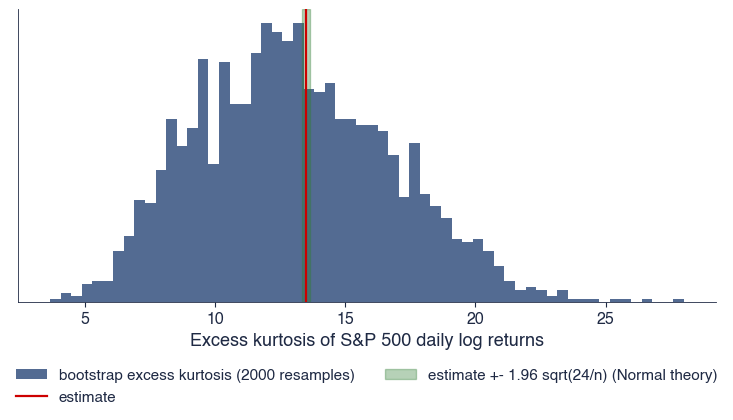

In [14]:
# Solution
def b1_moments(name='sp500', start=SEM_START, B=2000, plot=True, save=True):
    """Moments of daily log returns, Normal-theory standard errors, the Jarque-Bera test and bootstrap intervals."""
    r = returns(name, start)
    m = moments(r)
    bs_s, bs_k = bootstrap_moments(r, B)
    m.update(bs_s_lo=float(np.percentile(bs_s, 2.5)), bs_s_hi=float(np.percentile(bs_s, 97.5)),
             bs_k_lo=float(np.percentile(bs_k, 2.5)), bs_k_hi=float(np.percentile(bs_k, 97.5)),
             bs_k_sd=float(bs_k.std()), bs_s_sd=float(bs_s.std()),
             n_lo_k=m['exkurt'] - 1.96 * m['se_kurt'], n_hi_k=m['exkurt'] + 1.96 * m['se_kurt'])
    if plot:
        fig, ax = plt.subplots(figsize=(9, 3.8))
        ax.hist(bs_k, bins=60, density=True, color=COLORS[name], alpha=0.75, label=f'bootstrap excess kurtosis ({B} resamples)')
        ax.axvline(m['exkurt'], color=PAL['red'], lw=1.6, label='estimate')
        ax.axvspan(m['exkurt'] - 1.96 * m['se_kurt'], m['exkurt'] + 1.96 * m['se_kurt'], color=PAL['green'], alpha=0.35,
                   label='estimate +- 1.96 sqrt(24/n) (Normal theory)')
        ax.set_xlabel(f'Excess kurtosis of {SHORT[name]} daily log returns')
        ax.set_yticks([])
        st.legend_outside_bottom(ax, ncol=2, y=-0.18)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch2_sem_b1')
    return m


pd.Series(b1_moments(save=False))

**Interpretation of the result.** $\sqrt{24/n}$ assumes Normal data; with heavy tails the kurtosis depends on a few days, so its sampling variability is many times larger.

## B2 [Proposed]: three more series

**Question.** Which of the BET, Bitcoin and OMV Petrom is farthest from the Normal distribution, and how much does one day matter? Model: B1.

1. Compute $n$, mean, standard deviation, $S$, $K$ and JB for each series.
2. Remove the single largest absolute return of each series and recompute $K$.
3. Interpretation: what does the change in $K$ tell you about kurtosis as a summary of risk?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: Normal or Student-t for the BET?

**Question.** Does a Student-t describe the daily returns of the BET better than the Normal distribution, and where does each fail?

1. Draw the QQ plot of the standardised returns against $N(0,1)$.
2. Fit a Student-t by maximum likelihood and draw the QQ plot against the fitted t.
3. Compare the log-likelihoods and the AIC of the two models.
4. Interpretation: where does the Normal fail, and where does the fitted t fail?

**Report:** $\hat\nu$, $\hat m$, $\hat s$, two AIC values, two QQ plots, one sentence.

nu             2.964042
loc            0.078117
scale          0.628186
ll_t       -5496.408212
ll_n       -6224.209423
aic_t      10998.816424
aic_n      12452.418846
sd_t           1.101495
n           4186.000000
min          -11.892007
max           10.564512
q_t_min      -13.411458
q_n_min       -3.886635
daic        1453.602423
dtype: float64

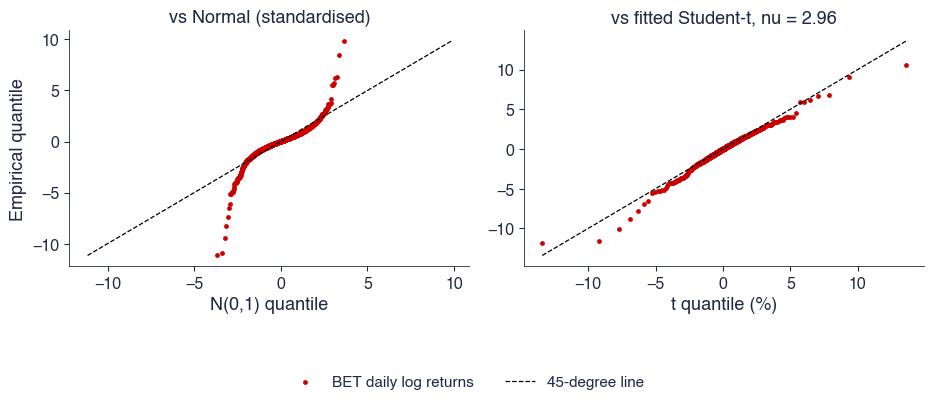

In [16]:
# Solution
def b3_qq(name='bet', start=SEM_START, plot=True, save=True):
    """QQ plots against the Normal and against the fitted Student-t; AIC of the two models."""
    r = returns(name, start)
    f = t_fit(r)
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
        tq, eq = qq_points(r)
        axes[0].scatter(tq, eq, s=6, color=COLORS[name], label=f'{SHORT[name]} daily log returns')
        tq2, eq2 = qq_points(r, 't', (f['nu'], f['loc'], f['scale']))
        axes[1].scatter(tq2, eq2, s=6, color=COLORS[name], label='_')
        for ax, (a, b) in zip(axes, [(tq, eq), (tq2, eq2)]):
            lim = [min(a.min(), b.min()), max(a.max(), b.max())]
            ax.plot(lim, lim, color='black', lw=0.9, ls='--', label='45-degree line' if ax is axes[0] else '_')
        axes[0].set_title('vs Normal (standardised)')
        axes[1].set_title(f"vs fitted Student-t, nu = {f['nu']:.2f}")
        axes[0].set_xlabel('N(0,1) quantile')
        axes[1].set_xlabel('t quantile (%)')
        axes[0].set_ylabel('Empirical quantile')
        st.fig_legend_bottom(fig, ncol=2, y=0.0)
        fig.tight_layout(rect=(0, 0.08, 1, 1))
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch2_sem_b3')
    rs = np.sort(r.values)
    n = len(rs)
    return {**f, 'n': n, 'min': float(rs[0]), 'max': float(rs[-1]),
            'q_t_min': float(stats.t.ppf(0.5 / n, f['nu'], f['loc'], f['scale'])),
            'q_n_min': float(r.mean() + r.std() * stats.norm.ppf(0.5 / n)),
            'daic': f['aic_n'] - f['aic_t']}


pd.Series(b3_qq(save=False))

**Interpretation of the result.** The Normal misses both tails (S-shape); the t fits the centre and most of the tails, but its most extreme quantiles go slightly beyond the data.

## B4 [Proposed]: how many 4-sigma days?

**Question.** How many 4-sigma days do the S&P 500, DAX, BET and Bitcoin have, and which model predicts the count? Model: B3.

1. Count the days with $|r_t - \bar r| > 4s$ in each series.
2. Compute the expected count under the Normal distribution and the Poisson probability of the observed count.
3. Compute the expected count under the fitted Student-t (same threshold).
4. Interpretation: is the Student-t too heavy, too light or about right for each series?

**Report:** one table and one sentence per series.

In [ ]:
# Your code here


## B5 [Solved]: does the S&P 500 become Normal at longer horizons?

**Question.** Are 5-day and 21-day returns of the S&P 500 closer to the Normal distribution than daily returns?

1. Build the 5-day and 21-day log returns (non-overlapping blocks).
2. Compute $n$, $S$, $K$, $\sqrt{24/n}$ and JB with its $p$-value at $h = 1, 5, 21$.
3. Draw the three QQ plots against $N(0,1)$.
4. Interpretation: is the monthly distribution Normal, and why does the test have less power at $h = 21$?

**Report:** a table with three rows, three QQ plots, two sentences.

,n,skew,exkurt,jb,jb_p,se_k
1,4201.0,-0.606031,13.490347,32112.889547,0.000000e+00,0.075584
5,840.0,-0.620237,7.057772,1797.282293,0.000000e+00,0.169031
21,200.0,-1.181225,3.675042,159.059225,2.888871e-35,0.346410


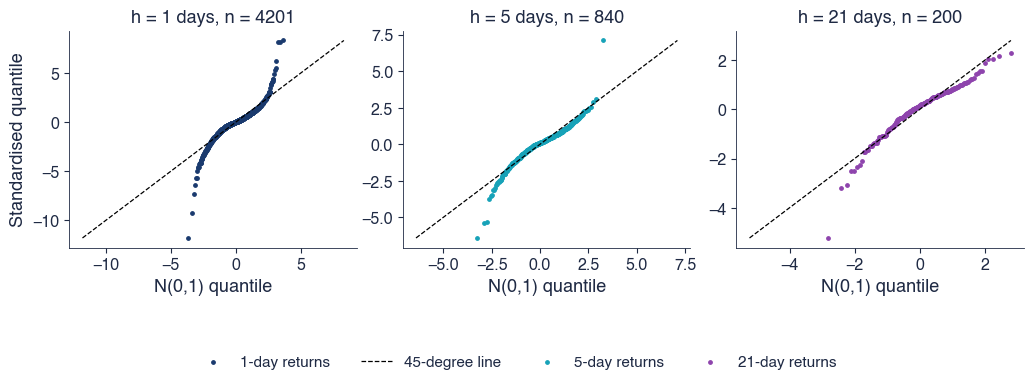

In [18]:
# Solution
def b5_aggregation(name='sp500', start=SEM_START, horizons=(1, 5, 21), plot=True, save=True):
    """Aggregational Gaussianity: skewness, excess kurtosis and the Jarque-Bera test at several horizons."""
    r = returns(name, start)
    out = {}
    for h in horizons:
        x = aggregate(r, h)
        m = moments(x)
        out[h] = {'n': m['n'], 'skew': m['skew'], 'exkurt': m['exkurt'], 'jb': m['jb'], 'jb_p': m['jb_p'],
                  'se_k': m['se_kurt']}
    if plot:
        fig, axes = plt.subplots(1, len(horizons), figsize=(10.5, 3.5))
        for ax, h, c in zip(axes, horizons, [COLORS[name], PAL['teal'], PAL['purple']]):
            tq, eq = qq_points(aggregate(r, h))
            ax.scatter(tq, eq, s=6, color=c, label=f'{h}-day returns')
            lim = [min(tq.min(), eq.min()), max(tq.max(), eq.max())]
            ax.plot(lim, lim, color='black', lw=0.9, ls='--', label='45-degree line' if h == horizons[0] else '_')
            ax.set_title(f'h = {h} days, n = {out[h]["n"]}')
            ax.set_xlabel('N(0,1) quantile')
        axes[0].set_ylabel('Standardised quantile')
        st.fig_legend_bottom(fig, ncol=4, y=0.0)
        fig.tight_layout(rect=(0, 0.08, 1, 1))
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch2_sem_b5')
    return out


pd.DataFrame(b5_aggregation(save=False)).T

**Interpretation of the result.** The kurtosis falls with the horizon, but monthly returns are still not Normal (March 2020); with 200 months the test detects only large departures.

## B6 [Proposed]: are BET returns independent?

**Question.** Are the daily returns of the BET uncorrelated, and are they independent? Model: B5.

1. Compute the ACF of $r_t$ and of $|r_t|$ at lags 1-10 and the band $\pm 1.96/\sqrt n$.
2. Compute the Ljung-Box statistic $Q(10)$ for $r_t$ and for $|r_t|$ and compare with $\chi^2_{0.95}(10)$.
3. Interpretation: can returns be uncorrelated but not independent?

**Report:** two ACF columns, two $Q$ values, one sentence.

In [ ]:
# Your code here


## B7 [Proposed]: is Bitcoin like a stock index?

**Question.** Do the S&P 500 and Bitcoin both show the leverage effect and the gain/loss asymmetry? Model: B5.

1. Compute $L(k) = \mathrm{Corr}(r_t, |r_{t+k}|)$ for $k = 1..5$ and their mean, with the band $\pm 1.96/\sqrt n$.
2. Count the days below $\bar r - 4s$ and above $\bar r + 4s$; binomial test of equal probabilities.
3. Compare $|q_{0.01}|$ and $q_{0.99}$ and the skewness.
4. Interpretation: which stylised facts of stock indices does Bitcoin share?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: are Bitcoin's tails getting thinner?

**Question.** Has the tail of Bitcoin's daily returns become thinner since 2015? Models: B3, B5.

1. Fit a Student-t and compute the excess kurtosis for each calendar year, for Bitcoin and the S&P 500.
2. Compute the Spearman rank correlation between the year and $\hat\nu$.
3. Fit one t on 2015-2020 and one on 2021-2026 and compare $\hat\nu$.
4. Propose one way to make the answer more reliable.
5. Interpretation: what can a dozen yearly estimates tell us about a trend?

**Report:** a table, the rank correlation with its $p$-value, a short project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant described the daily S&P 500 returns of 2010-2026 and claimed:

- (a) since the Normal distribution has kurtosis 0, the kurtosis of the S&P 500 equals its excess kurtosis;
- (b) a JB $p$-value of 0.000 proves that the returns follow a Student-t distribution;
- (c) the observed number of 4-sigma days is just bad luck under the Normal distribution;
- (d) the lag-1 autocorrelation is small, so returns are independent and volatility cannot be predicted;
- (e) with yearly log returns $N(7\%, 18\%^2)$, the expected value of 100 after one year is $100e^{0.07}$.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
